In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
tf.random.uniform([1])

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.6645621], dtype=float32)>

Downloading the dataset from web directly

In [4]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [5]:
print(cifar10.load_data.__doc__)

Loads the CIFAR10 dataset.

    This is a dataset of 50,000 32x32 color training images and 10,000 test
    images, labeled over 10 categories. See more info at the
    [CIFAR homepage](https://www.cs.toronto.edu/~kriz/cifar.html).

    The classes are:

    | Label | Description |
    |:-----:|-------------|
    |   0   | airplane    |
    |   1   | automobile  |
    |   2   | bird        |
    |   3   | cat         |
    |   4   | deer        |
    |   5   | dog         |
    |   6   | frog        |
    |   7   | horse       |
    |   8   | ship        |
    |   9   | truck       |

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(50000, 32, 32, 3)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy array of labels (integers in range 0-9)
      with shape `(50000, 1)` for the training data.

    **`x_test`**: `uin

In [6]:
y_test[0][0]

3

we have to change our target labels to categorical if we dont want see the 
ValueError: Arguments target and output must have the same shape. Received: target.shape=(100, 1), output.shape=(100, 10)
Error

In [7]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [8]:
y_test[0][0]

0.0

our data input shape are betwin 0 and 255 and we need normalized

In [9]:
X_train = X_train / 255
X_test = X_test / 255

In [10]:
X_train.max()

1.0

In [11]:
reg = keras.regularizers.l2(0.0003)

Making Model

In [12]:
# model architecture
model = keras.models.Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',
                 kernel_regularizer=reg,input_shape=(32,32,3),name='conv1'))
model.add(Dropout(0.25,name = 'drop1'))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv2'))
model.add(Dropout(0.25,name = 'drop2'))
model.add(MaxPool2D(name='pool1'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv3'))
model.add(Dropout(0.25,name = 'drop3'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv4'))
model.add(Dropout(0.25,name = 'drop4'))
model.add(MaxPool2D(name='pool2'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv5'))
model.add(Dropout(0.25,name = 'drop5'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv6'))
model.add(Dropout(0.25,name = 'drop6'))
model.add(Flatten(name='flatten'))
model.add(Dense(units=512,activation='relu',name = 'hidden1',kernel_regularizer=reg))
model.add(Dropout(0.65,name = 'drop7'))
model.add(Dense(units=10,activation='softmax',kernel_regularizer=reg ,name = 'output'))

d:\python-venv\keras2\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.001,decay_steps=9600)

In [15]:
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()
metric = [tf.metrics.CategoricalAccuracy()]
model.compile(optimizer=opt , loss= loss , metrics= metric)

In [16]:
history = model.fit(X_train,y_train,epochs=100,batch_size=100,validation_split=0.2,verbose=2)

Epoch 1/100
400/400 - 66s - 165ms/step - categorical_accuracy: 0.3229 - loss: 1.9909 - val_categorical_accuracy: 0.4602 - val_loss: 1.6920
Epoch 2/100
400/400 - 91s - 228ms/step - categorical_accuracy: 0.4742 - loss: 1.5760 - val_categorical_accuracy: 0.5469 - val_loss: 1.4499
Epoch 3/100
400/400 - 87s - 218ms/step - categorical_accuracy: 0.5423 - loss: 1.4269 - val_categorical_accuracy: 0.5975 - val_loss: 1.3048
Epoch 4/100
400/400 - 92s - 231ms/step - categorical_accuracy: 0.5899 - loss: 1.3328 - val_categorical_accuracy: 0.6238 - val_loss: 1.2722
Epoch 5/100
400/400 - 91s - 228ms/step - categorical_accuracy: 0.6254 - loss: 1.2641 - val_categorical_accuracy: 0.6616 - val_loss: 1.1947
Epoch 6/100
400/400 - 93s - 232ms/step - categorical_accuracy: 0.6538 - loss: 1.1993 - val_categorical_accuracy: 0.6867 - val_loss: 1.1243
Epoch 7/100
400/400 - 145s - 361ms/step - categorical_accuracy: 0.6722 - loss: 1.1580 - val_categorical_accuracy: 0.7029 - val_loss: 1.0922
Epoch 8/100
400/400 - 88s 

For testing our model with the data that model never seen before

In [20]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - categorical_accuracy: 0.8276 - loss: 0.8612


[0.8612365126609802, 0.8276000022888184]

Visualizing our loss in tran and validation set per epoch

In [21]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

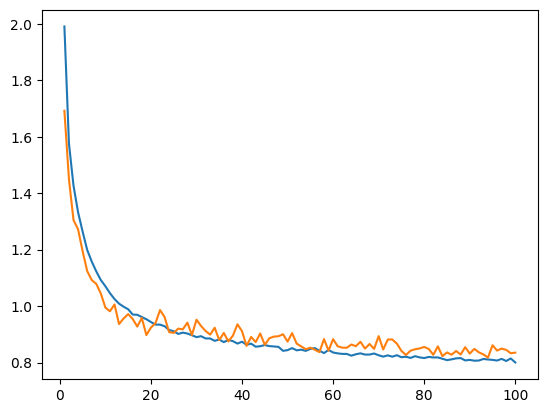

In [22]:
plt.plot(epochs , loss)
plt.plot(epochs , val_loss)